# Chapter 8 - RQ5 Distribution Shift

**Research question.** How do reconstruction quality and codebook usage change under distribution shift?

ImageNet is the fixed in-distribution reference. Every other dataset is compared with ImageNet within the same tokenizer. The analysis separates three effects:

1. reconstruction quality under shift;
2. changes in the global distribution of code assignments;
3. changes in where individual codes are deployed in the token grid.

The notebook consumes precomputed aggregate exports. Encoding remains in the model-specific export scripts; this notebook performs only lightweight aggregation, visualization, and chapter-ready export.


## 1. Data and Artifact Layout

Each run under `code_usage_results/<model>/<dataset>/` contains:

- `summary.json`: image count, grid dimensions, codebook size, active-code count, perplexity, and concentration summaries;
- `global_counts.npy`: count of every code over every image and grid position, shape `[K]`;
- `position_counts.npy`: count of every code at every grid location, shape `[K, H, W]`;
- `usage.csv`: tabular code counts and frequencies.

For a dataset with images $x_1,\ldots,x_N$ and token grids $z_i\in\{0,\ldots,K-1\}^{H\times W}$, the global count of code $k$ is

$$C_k=\sum_{i=1}^{N}\sum_{r=1}^{H}\sum_{c=1}^{W}\mathbf{1}[z_i(r,c)=k],$$

and the position-specific count is

$$C_{k,r,c}=\sum_{i=1}^{N}\mathbf{1}[z_i(r,c)=k].$$

Only aggregate counts are available. Consequently, the chapter reports dataset-level descriptive statistics; image-level bootstrapping or equal-size subsampling would require rerunning the exporters with saved per-image indices.


## 2. Setup and Reproducibility


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

np.random.seed(0)

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
})

MODEL_ORDER = ["LlamaGen", "VQGAN"]
MODEL_DIR_NAMES = {"LlamaGen": "llamagen", "VQGAN": "vqgan"}
MODEL_COLORS = {"LlamaGen": "#2F6F9F", "VQGAN": "#B85C38"}
DATASET_ORDER = [
    "imagenet", "imagenet_v2", "imagenet_sketch", "objectnet",
    "organamnist", "bloodmnist", "rvlcdip",
]
DATASET_LABELS = {
    "imagenet": "ImageNet",
    "imagenet_v2": "ImageNet-V2",
    "imagenet_sketch": "ImageNet-Sketch",
    "objectnet": "ObjectNet",
    "organamnist": "OrganAMNIST",
    "bloodmnist": "BloodMNIST",
    "rvlcdip": "RVL-CDIP",
}
IN_DISTRIBUTION_DATASET = "imagenet"
CODEBOOK_SIZE = 16_384
MIN_CODE_SUPPORT = 256


def find_notebook_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd / "notebooks", cwd.parent / "notebooks"]
    for candidate in candidates:
        if candidate.name == "notebooks" and candidate.exists():
            return candidate
    return cwd


NOTEBOOK_DIR = find_notebook_root()
REPO_ROOT = NOTEBOOK_DIR.parent
CODE_USAGE_ROOT = REPO_ROOT / "code_usage_results"
RECON_METRICS_PATH = NOTEBOOK_DIR / "data" / "end_to_end_metrics_numeric.csv"

OUTPUT_DIR = NOTEBOOK_DIR / "chapter8_outputs"
DATA_DIR = OUTPUT_DIR / "data"
FIGURE_DIR = OUTPUT_DIR / "figures"
CACHE_DIR = OUTPUT_DIR / "cache"
for directory in [DATA_DIR, FIGURE_DIR, CACHE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Notebook directory:", NOTEBOOK_DIR)
print("Code-usage results:", CODE_USAGE_ROOT)
print("Reconstruction metrics:", RECON_METRICS_PATH)
print("Chapter outputs:", OUTPUT_DIR)


Notebook directory: /exp/notebooks
Code-usage results: /exp/code_usage_results
Reconstruction metrics: /exp/notebooks/data/end_to_end_metrics_numeric.csv
Chapter outputs: /exp/notebooks/chapter8_outputs


## 3. Loading and Export Helpers


In [2]:
def save_table(df: pd.DataFrame, name: str) -> Path:
    path = DATA_DIR / name
    df.to_csv(path, index=False)
    print(f"saved: {path}")
    return path


def save_figure(fig: plt.Figure, name: str) -> Path:
    path = FIGURE_DIR / name
    fig.savefig(path, bbox_inches="tight")
    print(f"saved: {path}")
    return path


def load_run(model: str, dataset: str) -> dict:
    run_dir = CODE_USAGE_ROOT / MODEL_DIR_NAMES[model] / dataset
    return {
        "summary": json.loads((run_dir / "summary.json").read_text()),
        "global_counts": np.load(run_dir / "global_counts.npy"),
        "position_counts": np.load(run_dir / "position_counts.npy"),
        "usage": pd.read_csv(run_dir / "usage.csv"),
    }


def token_probabilities(counts: np.ndarray) -> np.ndarray:
    counts = counts.astype(np.float64)
    return counts / counts.sum()


def entropy_from_probs(probs: np.ndarray, axis=None) -> np.ndarray:
    terms = np.zeros_like(probs, dtype=np.float64)
    positive = probs > 0
    terms[positive] = probs[positive] * np.log(probs[positive])
    return -terms.sum(axis=axis)


def jensen_shannon_divergence(p: np.ndarray, q: np.ndarray) -> float:
    p = p / p.sum()
    q = q / q.sum()
    midpoint = 0.5 * (p + q)
    p_mask = p > 0
    q_mask = q > 0
    p_kl = np.sum(p[p_mask] * np.log(p[p_mask] / midpoint[p_mask]))
    q_kl = np.sum(q[q_mask] * np.log(q[q_mask] / midpoint[q_mask]))
    return float(0.5 * (p_kl + q_kl))


def position_entropy(position_counts: np.ndarray) -> np.ndarray:
    totals = position_counts.sum(axis=0, keepdims=True)
    probs = np.divide(
        position_counts,
        totals,
        out=np.zeros_like(position_counts, dtype=np.float64),
        where=totals > 0,
    )
    return entropy_from_probs(probs, axis=0)


def normalized_position_maps(position_counts: np.ndarray) -> np.ndarray:
    totals = position_counts.sum(axis=(1, 2), keepdims=True)
    return np.divide(
        position_counts,
        totals,
        out=np.zeros_like(position_counts, dtype=np.float64),
        where=totals > 0,
    )


## 4. Inventory and Validation


In [3]:
available = {
    model: {
        path.name
        for path in (CODE_USAGE_ROOT / MODEL_DIR_NAMES[model]).iterdir()
        if path.is_dir()
    }
    for model in MODEL_ORDER
}
shared = set.intersection(*available.values())
datasets = [dataset for dataset in DATASET_ORDER if dataset in shared]
ood_datasets = [dataset for dataset in datasets if dataset != IN_DISTRIBUTION_DATASET]
runs = {
    model: {dataset: load_run(model, dataset) for dataset in datasets}
    for model in MODEL_ORDER
}

inventory_rows = []
for model in MODEL_ORDER:
    for dataset in datasets:
        run = runs[model][dataset]
        summary = run["summary"]
        global_total = int(run["global_counts"].sum())
        position_total = int(run["position_counts"].sum())
        height, width = summary["token_grid_hw"]
        expected_total = int(summary["n_images"] * height * width)
        inventory_rows.append({
            "model": model,
            "dataset": dataset,
            "dataset_label": DATASET_LABELS[dataset],
            "n_images": int(summary["n_images"]),
            "grid_height": int(height),
            "grid_width": int(width),
            "total_tokens": global_total,
            "active_codes": int((run["global_counts"] > 0).sum()),
            "counts_consistent": global_total == position_total == expected_total,
        })

inventory_df = pd.DataFrame(inventory_rows)
save_table(inventory_df, "ch08_artifact_inventory.csv")
display(inventory_df)
assert inventory_df["counts_consistent"].all()


saved: /exp/notebooks/chapter8_outputs/data/ch08_artifact_inventory.csv


,model,dataset,dataset_label,n_images,grid_height,grid_width,total_tokens,active_codes,counts_consistent
0,LlamaGen,imagenet,ImageNet,50000,16,16,12800000,16384,True
1,LlamaGen,imagenet_v2,ImageNet-V2,10000,16,16,2560000,16384,True
2,LlamaGen,imagenet_sketch,ImageNet-Sketch,50889,16,16,13027584,16383,True
3,LlamaGen,objectnet,ObjectNet,50273,16,16,12869888,16384,True
4,LlamaGen,organamnist,OrganAMNIST,57187,16,16,14639872,16383,True
5,LlamaGen,bloodmnist,BloodMNIST,17092,16,16,4375552,16124,True
6,LlamaGen,rvlcdip,RVL-CDIP,39996,16,16,10238976,16288,True
7,VQGAN,imagenet,ImageNet,50000,16,16,12800000,972,True
8,VQGAN,imagenet_v2,ImageNet-V2,10000,16,16,2560000,972,True
9,VQGAN,imagenet_sketch,ImageNet-Sketch,50889,16,16,13027584,972,True


## 5. Metric Formalization

### Reconstruction quality

PSNR and SSIM are higher-is-better; LPIPS and FID are lower-is-better. PSNR, SSIM, and LPIPS compare each image with its reconstruction. FID compares dataset-level feature distributions and is interpreted only between models on the same dataset, since its scale also depends on domain content and sample size.

### Global code usage

The empirical probability of code $k$ is $p_k=C_k/\sum_j C_j$. We report:

- **perplexity** $\exp(-\sum_k p_k\log p_k)$, the effective global vocabulary size;
- **top-$K$ mass** $\sum_{k\in\operatorname{TopK}(p)}p_k$, code-usage concentration;
- **Jensen-Shannon divergence** between ImageNet and OOD code probabilities, a symmetric bounded measure that compares the same code indices within one model;
- **active-set retention and Jaccard overlap**, descriptive support measures that remain sample-size dependent.

### Spatial usage

At location $(r,c)$, positional entropy is $H(r,c)=-\sum_k p(k\mid r,c)\log p(k\mid r,c)$. For a fixed code, its position map is $p(r,c\mid k)$. Spatial comparisons are always made across datasets within the same model; numeric code IDs are not semantically aligned between LlamaGen and VQGAN.


## 6. Reconstruction Quality Under Shift


In [4]:
recon_df = pd.read_csv(RECON_METRICS_PATH)
dataset_key_map = {label: key for key, label in DATASET_LABELS.items()}
recon_df["dataset_key"] = recon_df["dataset"].map(dataset_key_map)
recon_df = recon_df[
    recon_df["model"].isin(MODEL_ORDER) & recon_df["dataset_key"].isin(datasets)
].copy()
recon_summary = recon_df[[
    "model", "dataset", "dataset_key",
    "psnr_mean", "psnr_std", "ssim_mean", "ssim_std",
    "lpips_mean", "lpips_std", "fid",
]].sort_values(["dataset_key", "model"])
save_table(recon_summary, "ch08_reconstruction_metrics.csv")
display(recon_summary)


saved: /exp/notebooks/chapter8_outputs/data/ch08_reconstruction_metrics.csv


,model,dataset,dataset_key,psnr_mean,psnr_std,ssim_mean,ssim_std,lpips_mean,lpips_std,fid
6,LlamaGen,BloodMNIST,bloodmnist,27.101034,2.457337,0.802003,0.076603,0.157412,0.029339,19.601578
13,VQGAN,BloodMNIST,bloodmnist,26.379670,2.887773,0.766061,0.090811,0.200647,0.039598,29.015836
0,LlamaGen,ImageNet,imagenet,20.793682,3.184499,0.558420,0.167186,0.228152,0.058472,2.190020
7,VQGAN,ImageNet,imagenet,19.649455,3.406491,0.488608,0.175846,0.285628,0.065720,5.055368
2,LlamaGen,ImageNet-Sketch,imagenet_sketch,20.258672,5.782762,0.752088,0.150456,0.127749,0.064468,3.688820
9,VQGAN,ImageNet-Sketch,imagenet_sketch,18.226843,4.386636,0.695854,0.170250,0.169755,0.077180,5.976393
1,LlamaGen,ImageNet-V2,imagenet_v2,20.953198,3.132404,0.571562,0.162310,0.230828,0.058943,4.340310
8,VQGAN,ImageNet-V2,imagenet_v2,19.831684,3.339825,0.501436,0.171765,0.288779,0.066414,7.479044
3,LlamaGen,ObjectNet,objectnet,23.878325,3.198101,0.683478,0.158483,0.207518,0.052531,2.932945
10,VQGAN,ObjectNet,objectnet,22.792442,3.608505,0.610994,0.175466,0.268003,0.060494,5.796088


## 7. Global Vocabulary Usage


In [5]:
global_rows = []
for model in MODEL_ORDER:
    baseline_counts = runs[model][IN_DISTRIBUTION_DATASET]["global_counts"]
    baseline_probs = token_probabilities(baseline_counts)
    baseline_active = baseline_counts > 0
    baseline_active_count = int(baseline_active.sum())

    for dataset in datasets:
        counts = runs[model][dataset]["global_counts"]
        probs = token_probabilities(counts)
        active = counts > 0
        entropy = float(entropy_from_probs(probs))
        intersection = int((active & baseline_active).sum())
        union = int((active | baseline_active).sum())
        sorted_probs = np.sort(probs)[::-1]
        global_rows.append({
            "model": model,
            "dataset": dataset,
            "dataset_label": DATASET_LABELS[dataset],
            "n_images": runs[model][dataset]["summary"]["n_images"],
            "active_codes": int(active.sum()),
            "active_fraction_full": float(active.mean()),
            "imagenet_active_retention": intersection / baseline_active_count,
            "active_set_jaccard": intersection / union,
            "perplexity": float(np.exp(entropy)),
            "perplexity_ratio_vs_imagenet": float(np.exp(entropy) / np.exp(entropy_from_probs(baseline_probs))),
            "top_10_mass": float(sorted_probs[:10].sum()),
            "top_100_mass": float(sorted_probs[:100].sum()),
            "top_500_mass": float(sorted_probs[:500].sum()),
            "js_divergence_vs_imagenet": jensen_shannon_divergence(baseline_probs, probs),
        })

global_summary = pd.DataFrame(global_rows)
save_table(global_summary, "ch08_global_code_usage.csv")
display(global_summary)


saved: /exp/notebooks/chapter8_outputs/data/ch08_global_code_usage.csv


,model,dataset,dataset_label,n_images,active_codes,active_fraction_full,imagenet_active_retention,active_set_jaccard,perplexity,perplexity_ratio_vs_imagenet,top_10_mass,top_100_mass,top_500_mass,js_divergence_vs_imagenet
0,LlamaGen,imagenet,ImageNet,50000,16384,1.000000,1.000000,1.000000,16179.189378,1.000000,0.002933,0.011967,0.045642,0.000000
1,LlamaGen,imagenet_v2,ImageNet-V2,10000,16384,1.000000,1.000000,1.000000,16094.903809,0.994790,0.002756,0.012407,0.047786,0.002027
2,LlamaGen,imagenet_sketch,ImageNet-Sketch,50889,16383,0.999939,0.999939,0.999939,6095.064781,0.376723,0.095202,0.186389,0.302988,0.153144
3,LlamaGen,objectnet,ObjectNet,50273,16384,1.000000,1.000000,1.000000,14817.435854,0.915833,0.006668,0.029941,0.089336,0.020025
4,LlamaGen,organamnist,OrganAMNIST,57187,16383,0.999939,0.999939,0.999939,10099.191216,0.624209,0.026950,0.070029,0.167338,0.103524
5,LlamaGen,bloodmnist,BloodMNIST,17092,16124,0.984131,0.984131,0.984131,5810.776916,0.359151,0.023922,0.129320,0.323858,0.225963
6,LlamaGen,rvlcdip,RVL-CDIP,39996,16288,0.994141,0.994141,0.994141,3721.318354,0.230006,0.113131,0.216333,0.367508,0.250985
7,VQGAN,imagenet,ImageNet,50000,972,0.059326,1.000000,1.000000,910.464663,1.000000,0.021549,0.164769,0.664882,0.000000
8,VQGAN,imagenet_v2,ImageNet-V2,10000,972,0.059326,1.000000,1.000000,911.084478,1.000681,0.021474,0.164576,0.663230,0.000388
9,VQGAN,imagenet_sketch,ImageNet-Sketch,50889,972,0.059326,1.000000,1.000000,411.380910,0.451836,0.228792,0.455783,0.850975,0.127654


saved: /exp/notebooks/chapter8_outputs/figures/ch08_global_shift_summary.png


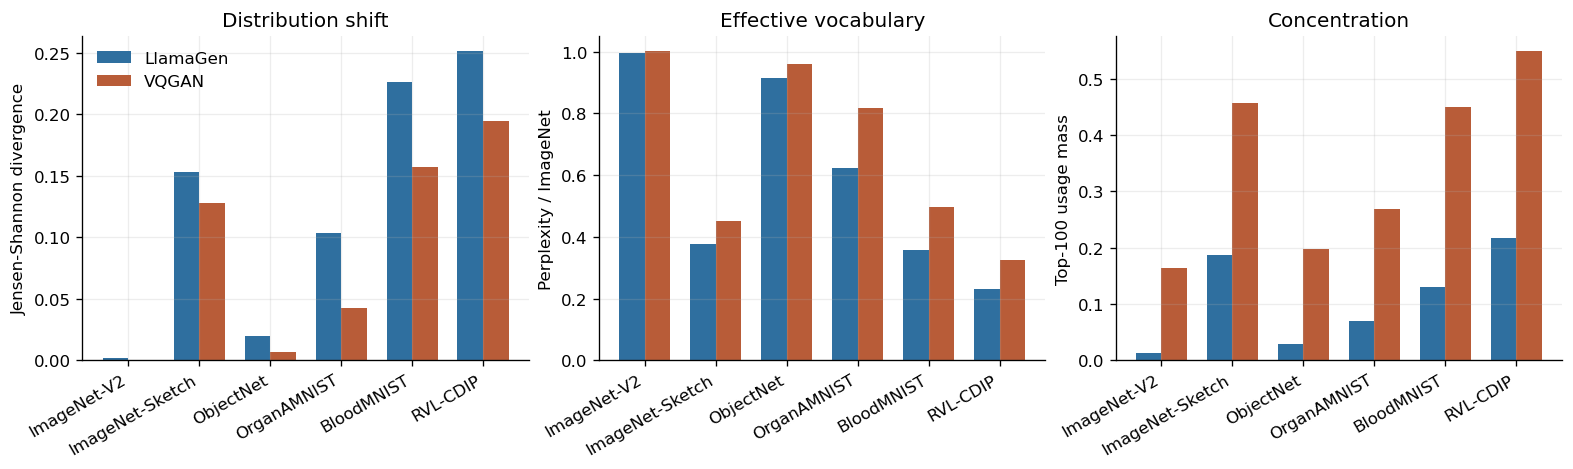

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), constrained_layout=True)
metric_specs = [
    ("js_divergence_vs_imagenet", "Jensen-Shannon divergence", "Distribution shift"),
    ("perplexity_ratio_vs_imagenet", "Perplexity / ImageNet", "Effective vocabulary"),
    ("top_100_mass", "Top-100 usage mass", "Concentration"),
]
x = np.arange(len(ood_datasets))
width = 0.36
for ax, (metric, ylabel, title) in zip(axes, metric_specs):
    for offset, model in [(-width / 2, "LlamaGen"), (width / 2, "VQGAN")]:
        values = (
            global_summary[(global_summary["model"] == model)]
            .set_index("dataset").loc[ood_datasets, metric].to_numpy()
        )
        ax.bar(x + offset, values, width, color=MODEL_COLORS[model], label=model)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels([DATASET_LABELS[d] for d in ood_datasets], rotation=30, ha="right")
axes[0].legend(frameon=False)
save_figure(fig, "ch08_global_shift_summary.png")
plt.show()


### Ranked Usage and Reconstruction Together

Ranked curves describe concentration, not code identity: rank 1 is the most frequently used code in each dataset and need not refer to the same code index. The reconstruction panels below each pair keep distribution shift and reconstruction quality visible in the same view.


saved: /exp/notebooks/chapter8_outputs/figures/ch08_usage_reconstruction_imagenet_v2.png


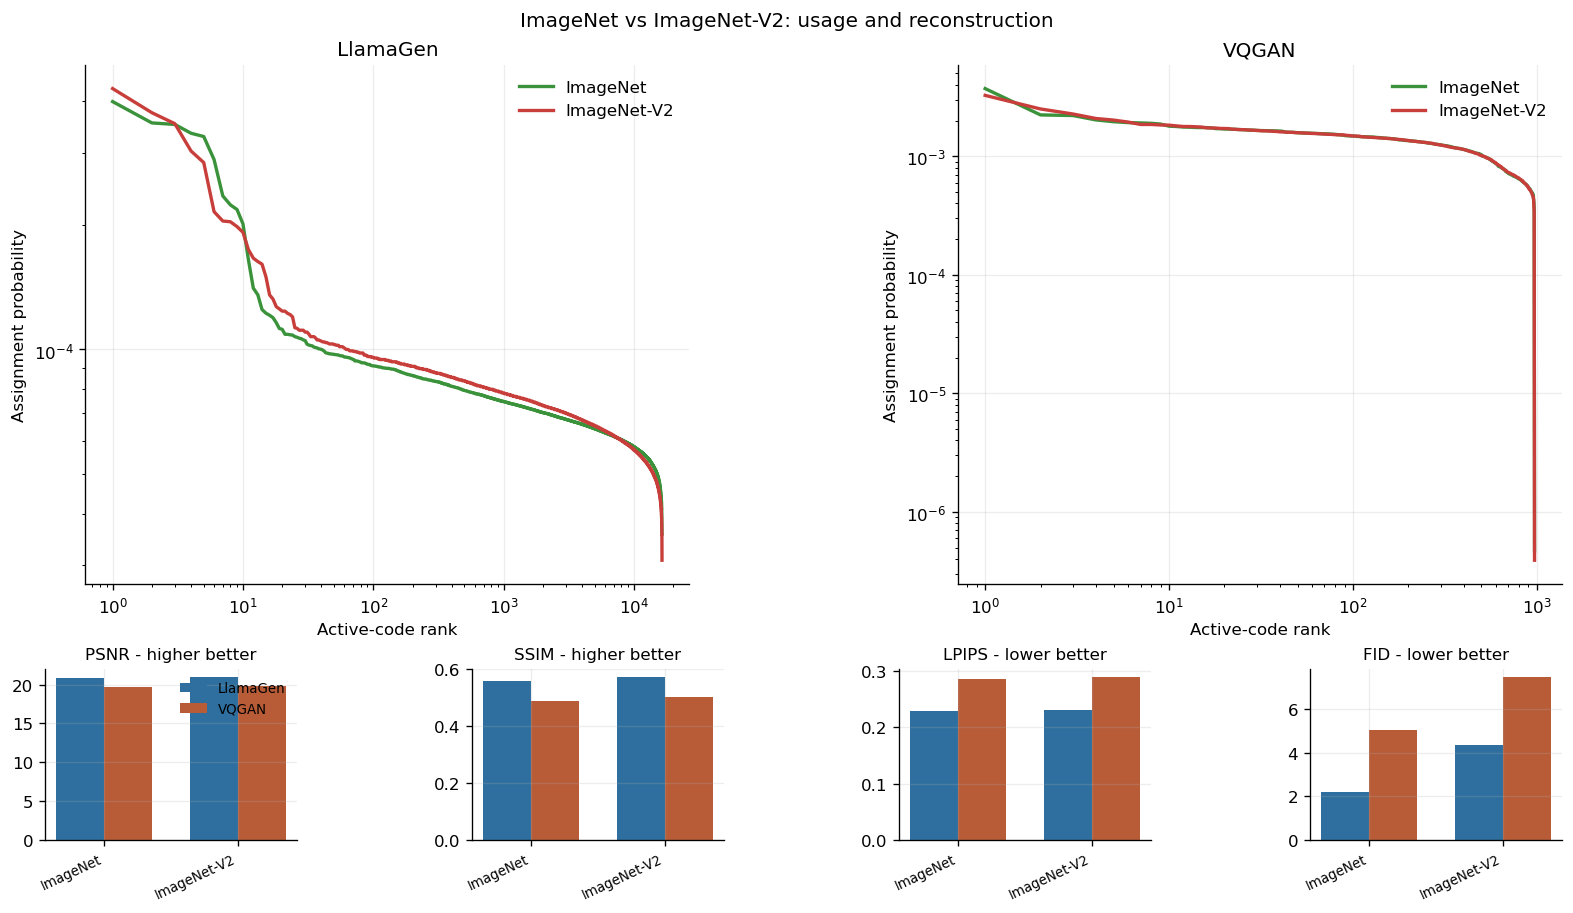

saved: /exp/notebooks/chapter8_outputs/figures/ch08_usage_reconstruction_imagenet_sketch.png


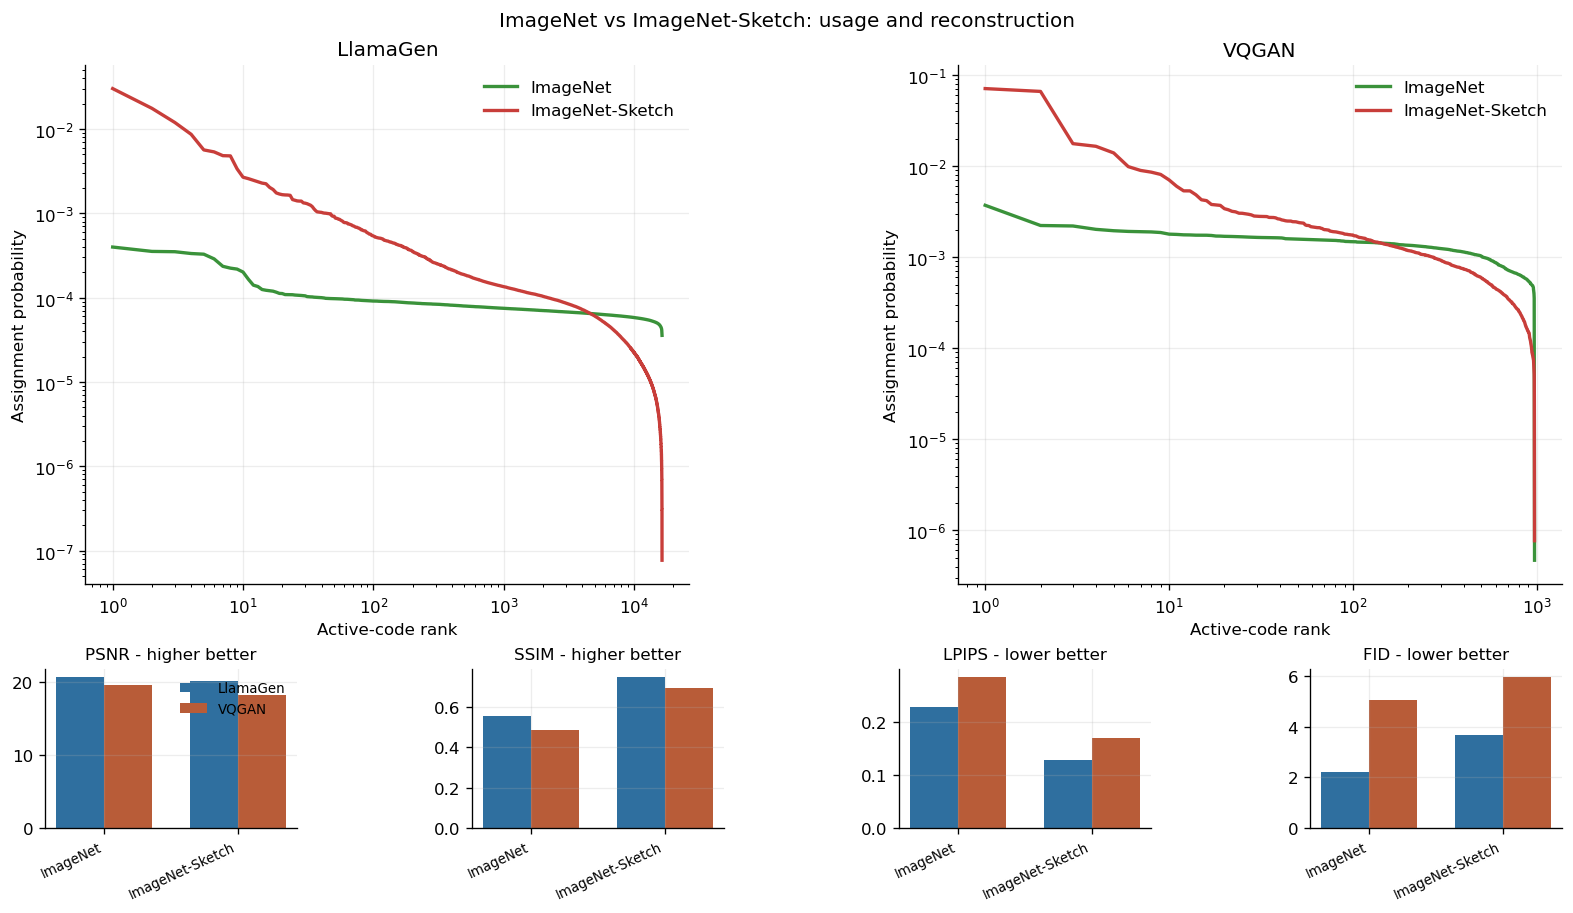

saved: /exp/notebooks/chapter8_outputs/figures/ch08_usage_reconstruction_objectnet.png


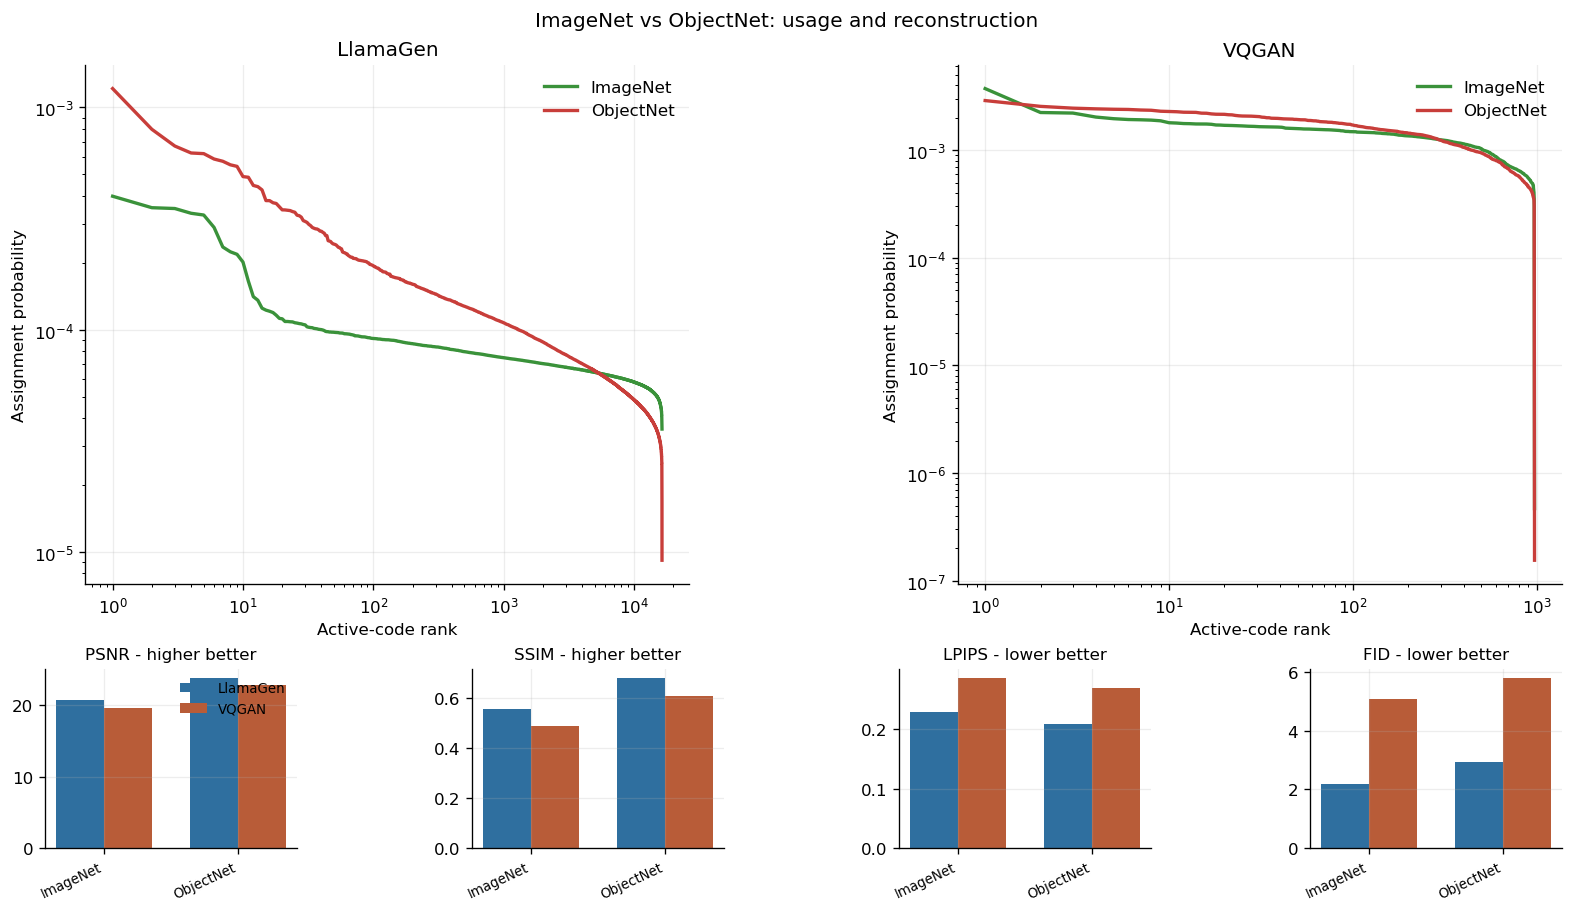

saved: /exp/notebooks/chapter8_outputs/figures/ch08_usage_reconstruction_organamnist.png


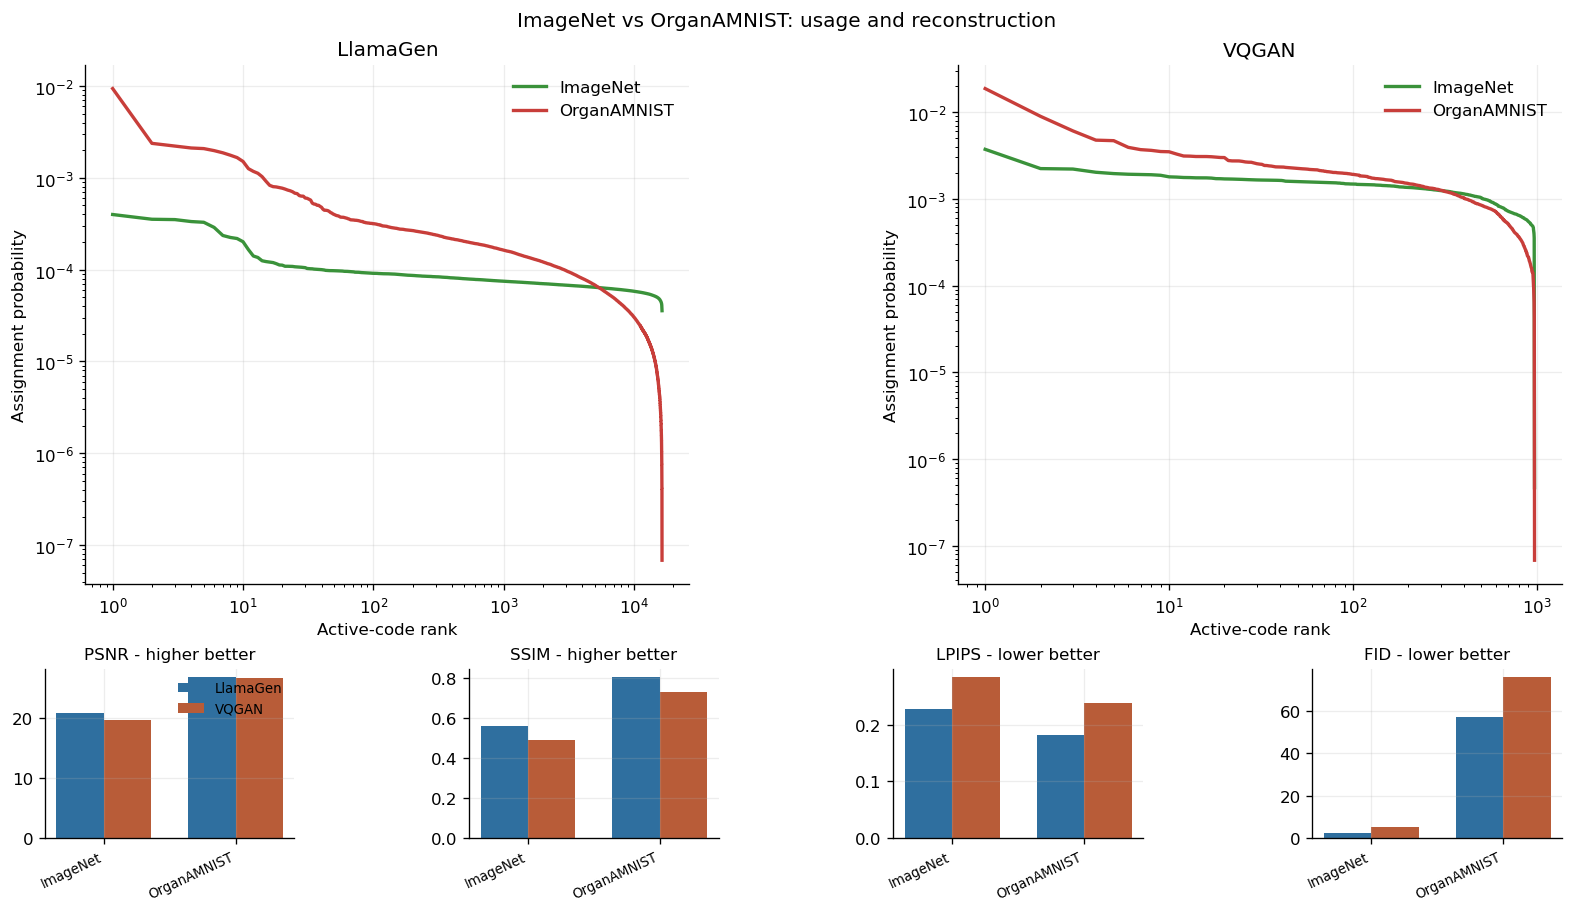

saved: /exp/notebooks/chapter8_outputs/figures/ch08_usage_reconstruction_bloodmnist.png


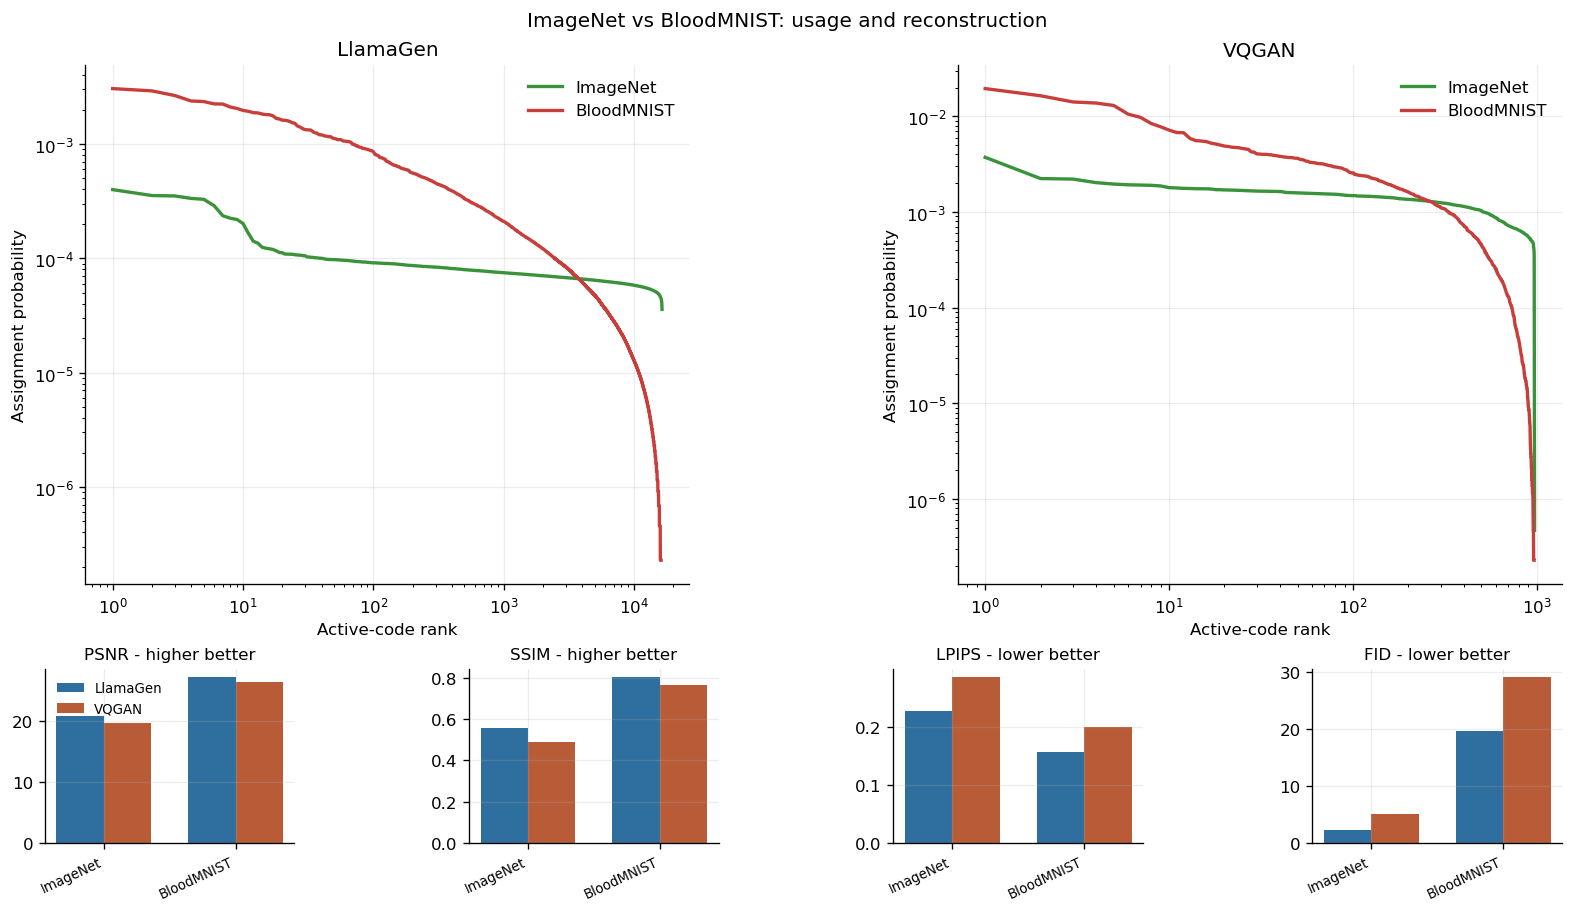

saved: /exp/notebooks/chapter8_outputs/figures/ch08_usage_reconstruction_rvlcdip.png


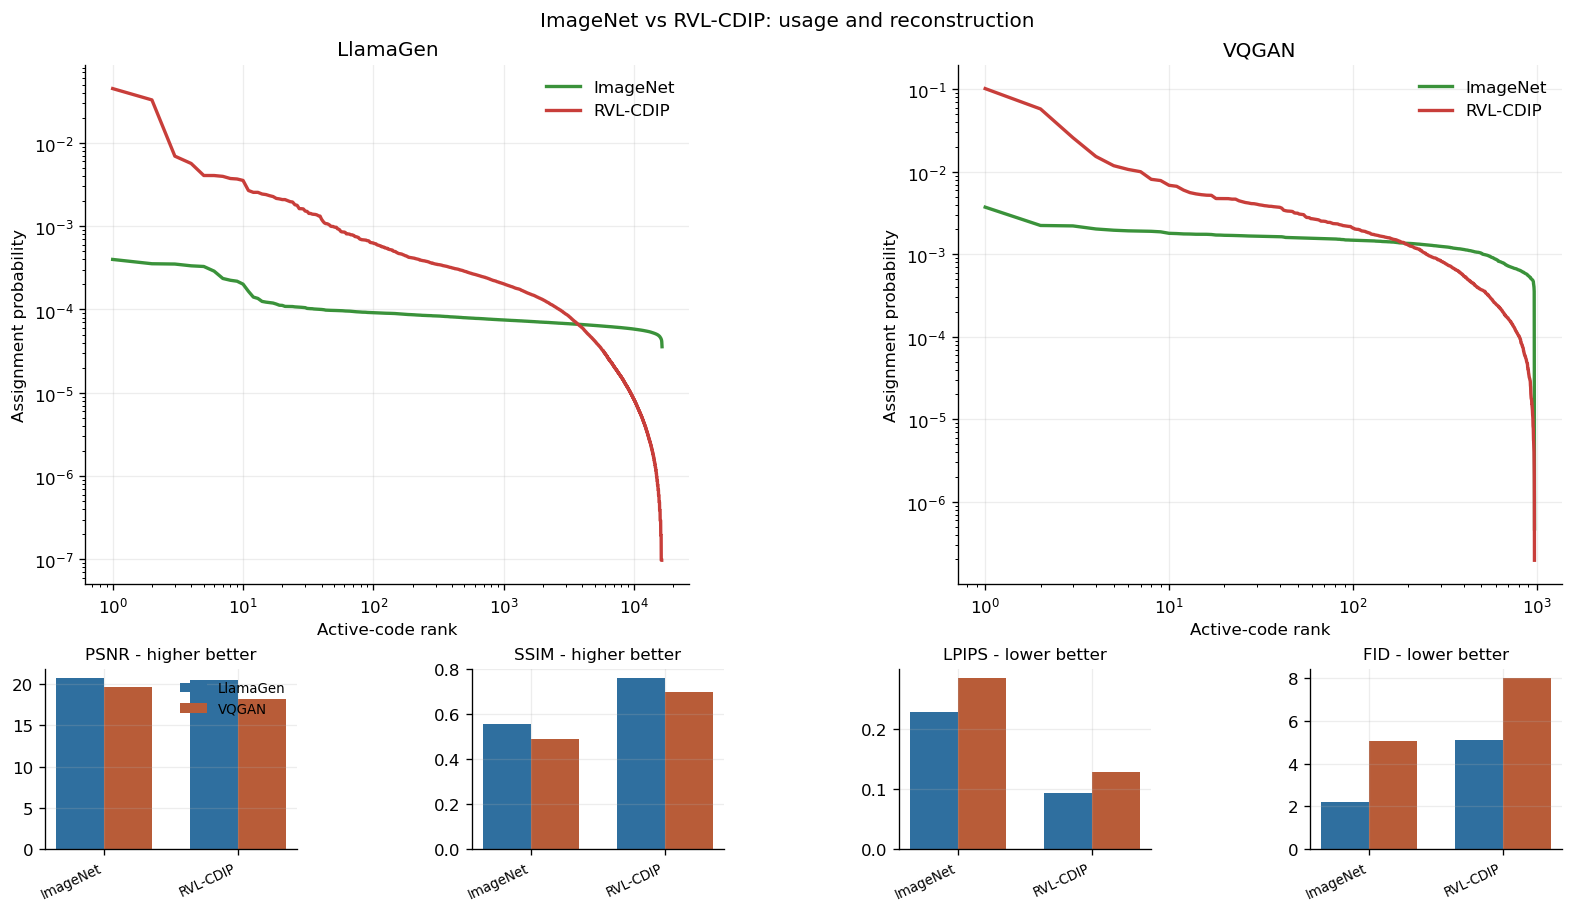

In [7]:
recon_metrics = [
    ("psnr_mean", "PSNR", "higher better"),
    ("ssim_mean", "SSIM", "higher better"),
    ("lpips_mean", "LPIPS", "lower better"),
    ("fid", "FID", "lower better"),
]

for ood_dataset in ood_datasets:
    focus = [IN_DISTRIBUTION_DATASET, ood_dataset]
    fig = plt.figure(figsize=(13, 7.5), constrained_layout=True)
    outer = fig.add_gridspec(2, 1, height_ratios=[2.3, 1.0])
    curve_axes = outer[0].subgridspec(1, 2, wspace=0.25).subplots()
    metric_axes = outer[1].subgridspec(1, 4, wspace=0.35).subplots()

    for ax, model in zip(curve_axes, MODEL_ORDER):
        for dataset, color in [(IN_DISTRIBUTION_DATASET, "#3A923A"), (ood_dataset, "#C83E3A")]:
            probs = token_probabilities(runs[model][dataset]["global_counts"])
            ranked = np.sort(probs[probs > 0])[::-1]
            ax.plot(np.arange(1, len(ranked) + 1), ranked, color=color, linewidth=2,
                    label=DATASET_LABELS[dataset])
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_title(model)
        ax.set_xlabel("Active-code rank")
        ax.set_ylabel("Assignment probability")
        ax.legend(frameon=False)

    metric_focus = recon_df[recon_df["dataset_key"].isin(focus)]
    positions = np.arange(2)
    for ax, (metric, label, direction) in zip(metric_axes, recon_metrics):
        for offset, model in [(-width / 2, "LlamaGen"), (width / 2, "VQGAN")]:
            values = metric_focus[metric_focus["model"] == model].set_index("dataset_key").loc[focus, metric]
            ax.bar(positions + offset, values, width, color=MODEL_COLORS[model], label=model)
        ax.set_title(f"{label} - {direction}", fontsize=10)
        ax.set_xticks(positions)
        ax.set_xticklabels([DATASET_LABELS[d] for d in focus], rotation=25, ha="right", fontsize=8)
    metric_axes[0].legend(frameon=False, fontsize=8)
    fig.suptitle(f"ImageNet vs {DATASET_LABELS[ood_dataset]}: usage and reconstruction")
    save_figure(fig, f"ch08_usage_reconstruction_{ood_dataset}.png")
    plt.show()


## 8. Positional Entropy Under Shift

At each grid location, entropy is estimated from one code assignment per image. Consequently, datasets with fewer images have a lower finite-sample entropy ceiling and a larger downward bias, especially for LlamaGen's 16,384-code vocabulary. The heatmaps therefore show the combined effect of dataset shift and sample size; they are descriptive spatial signatures, not sample-size-controlled estimates of shift.


In [8]:
entropy_grids = {
    model: {
        dataset: position_entropy(runs[model][dataset]["position_counts"])
        for dataset in datasets
    }
    for model in MODEL_ORDER
}

entropy_rows = []
for model in MODEL_ORDER:
    baseline = entropy_grids[model][IN_DISTRIBUTION_DATASET]
    for dataset in ood_datasets:
        delta = entropy_grids[model][dataset] - baseline
        border = np.zeros(delta.shape, dtype=bool)
        border[[0, -1], :] = True
        border[:, [0, -1]] = True
        entropy_rows.append({
            "model": model,
            "dataset": dataset,
            "dataset_label": DATASET_LABELS[dataset],
            "mean_entropy_delta": float(delta.mean()),
            "median_entropy_delta": float(np.median(delta)),
            "mean_absolute_entropy_delta": float(np.abs(delta).mean()),
            "border_entropy_delta": float(delta[border].mean()),
            "interior_entropy_delta": float(delta[~border].mean()),
        })

entropy_summary = pd.DataFrame(entropy_rows)
save_table(entropy_summary, "ch08_positional_entropy_summary.csv")
display(entropy_summary)


saved: /exp/notebooks/chapter8_outputs/data/ch08_positional_entropy_summary.csv


,model,dataset,dataset_label,mean_entropy_delta,median_entropy_delta,mean_absolute_entropy_delta,border_entropy_delta,interior_entropy_delta
0,LlamaGen,imagenet_v2,ImageNet-V2,-0.682498,-0.684026,0.682498,-0.671652,-0.685818
1,LlamaGen,imagenet_sketch,ImageNet-Sketch,-1.165705,-0.969014,1.165705,-2.211512,-0.845559
2,LlamaGen,objectnet,ObjectNet,-0.297874,-0.080199,0.297874,-0.923971,-0.106212
3,LlamaGen,organamnist,OrganAMNIST,-0.543501,-0.536826,0.543501,-0.613048,-0.522211
4,LlamaGen,bloodmnist,BloodMNIST,-1.551854,-1.539349,1.551854,-2.006522,-1.412670
5,LlamaGen,rvlcdip,RVL-CDIP,-1.667851,-1.484562,1.667851,-2.446791,-1.429400
6,VQGAN,imagenet_v2,ImageNet-V2,-0.039035,-0.039643,0.039035,-0.033938,-0.040596
7,VQGAN,imagenet_sketch,ImageNet-Sketch,-0.904052,-0.764277,0.904052,-1.797740,-0.630474
8,VQGAN,objectnet,ObjectNet,-0.130847,-0.062888,0.131838,-0.350470,-0.063616
9,VQGAN,organamnist,OrganAMNIST,-0.248847,-0.260955,0.248847,-0.214995,-0.259209


saved: /exp/notebooks/chapter8_outputs/figures/ch08_positional_entropy_deltas.png


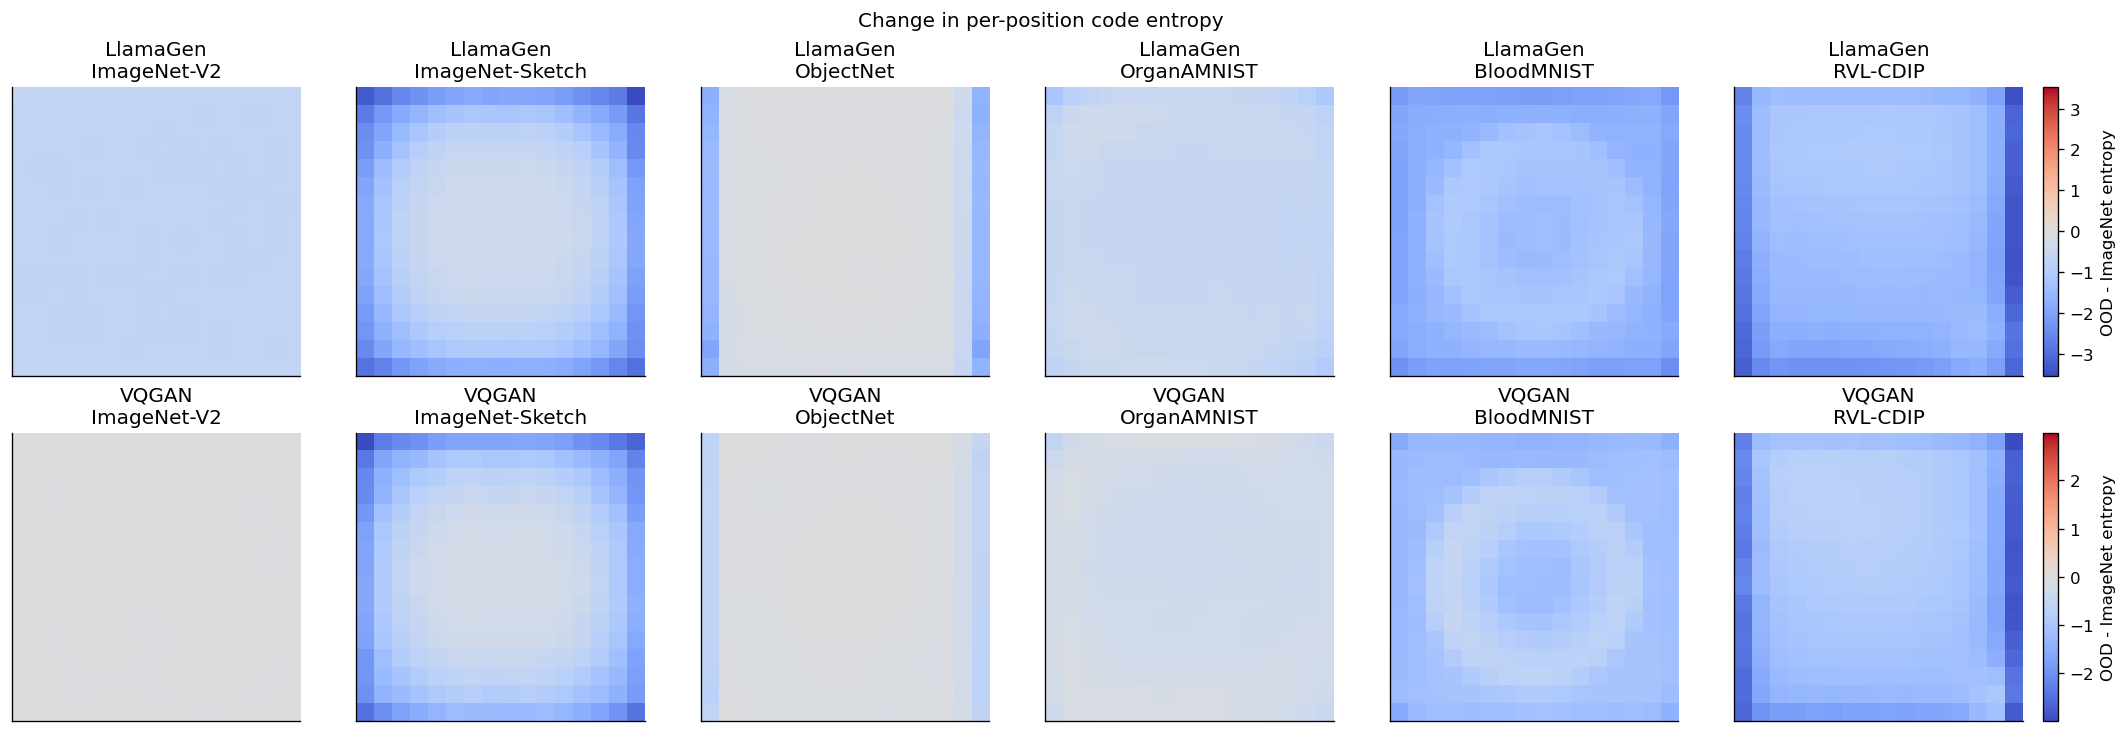

In [9]:
fig, axes = plt.subplots(2, len(ood_datasets), figsize=(3 * len(ood_datasets), 6), constrained_layout=True)
for row, model in enumerate(MODEL_ORDER):
    deltas = [
        entropy_grids[model][dataset] - entropy_grids[model][IN_DISTRIBUTION_DATASET]
        for dataset in ood_datasets
    ]
    limit = max(np.abs(delta).max() for delta in deltas)
    for col, (dataset, delta) in enumerate(zip(ood_datasets, deltas)):
        ax = axes[row, col]
        image = ax.imshow(delta, vmin=-limit, vmax=limit, cmap="coolwarm")
        ax.set_title(f"{model}\n{DATASET_LABELS[dataset]}")
        ax.set_xticks([])
        ax.set_yticks([])
    fig.colorbar(image, ax=axes[row, :], fraction=0.018, pad=0.01, label="OOD - ImageNet entropy")
fig.suptitle("Change in per-position code entropy")
save_figure(fig, "ch08_positional_entropy_deltas.png")
plt.show()


## 9. Systematic Code-Specific Spatial Shift

The exploratory notebook displayed the first three numeric code IDs active in both models. That cannot establish a general effect, and identical numeric IDs do not align semantics across independently learned codebooks.

Here each model is analyzed independently. A code is eligible for an ImageNet/OOD pair when it appears at least `MIN_CODE_SUPPORT` times in both datasets. For every eligible code we compare $p(r,c\mid k)$ and report:

- **L1 spatial distance**, from 0 for identical position maps to 2 for disjoint maps;
- **effective spatial support**, $\exp(H[p(r,c\mid k)])$;
- **zero-position fraction**, the fraction of grid cells where the code was never observed;
- **maximum-position mass**, the strongest single-cell concentration.

The support threshold corresponds to only one occurrence per grid location on average. It removes the rarest codes, but it does not make every spatial map statistically stable. This matters most for LlamaGen: many eligible OOD codes average only 1--3 observations per cell, so their L1 distance and apparent support contraction include finite-sample noise. VQGAN's smaller active vocabulary gives its eligible codes substantially more observations per cell. Spatial magnitudes should therefore be interpreted within a model and as exploratory evidence, not as a direct robustness ranking between models.


In [10]:
spatial_frames = []
for model in MODEL_ORDER:
    baseline_counts = runs[model][IN_DISTRIBUTION_DATASET]["position_counts"]
    baseline_totals = baseline_counts.sum(axis=(1, 2))
    baseline_maps = normalized_position_maps(baseline_counts)
    baseline_entropy = entropy_from_probs(baseline_maps, axis=(1, 2))
    baseline_support = np.exp(baseline_entropy)

    for dataset in ood_datasets:
        shifted_counts = runs[model][dataset]["position_counts"]
        shifted_totals = shifted_counts.sum(axis=(1, 2))
        eligible = (baseline_totals >= MIN_CODE_SUPPORT) & (shifted_totals >= MIN_CODE_SUPPORT)
        code_ids = np.flatnonzero(eligible)
        shifted_maps = normalized_position_maps(shifted_counts)
        shifted_entropy = entropy_from_probs(shifted_maps, axis=(1, 2))
        shifted_support = np.exp(shifted_entropy)

        frame = pd.DataFrame({
            "model": model,
            "dataset": dataset,
            "dataset_label": DATASET_LABELS[dataset],
            "code_id": code_ids,
            "imagenet_code_total": baseline_totals[eligible].astype(np.int64),
            "ood_code_total": shifted_totals[eligible].astype(np.int64),
            "l1_spatial_distance": np.abs(shifted_maps[eligible] - baseline_maps[eligible]).sum(axis=(1, 2)),
            "imagenet_effective_support": baseline_support[eligible],
            "ood_effective_support": shifted_support[eligible],
            "effective_support_ratio": shifted_support[eligible] / baseline_support[eligible],
            "imagenet_zero_fraction": (baseline_maps[eligible] == 0).mean(axis=(1, 2)),
            "ood_zero_fraction": (shifted_maps[eligible] == 0).mean(axis=(1, 2)),
            "imagenet_max_position_mass": baseline_maps[eligible].max(axis=(1, 2)),
            "ood_max_position_mass": shifted_maps[eligible].max(axis=(1, 2)),
        })
        frame["zero_fraction_delta"] = frame["ood_zero_fraction"] - frame["imagenet_zero_fraction"]
        frame["max_position_mass_delta"] = frame["ood_max_position_mass"] - frame["imagenet_max_position_mass"]
        spatial_frames.append(frame)

spatial_code_shift = pd.concat(spatial_frames, ignore_index=True)
save_table(spatial_code_shift, "ch08_code_spatial_shift_all_codes.csv")
display(spatial_code_shift.head())


saved: /exp/notebooks/chapter8_outputs/data/ch08_code_spatial_shift_all_codes.csv


,model,dataset,dataset_label,code_id,imagenet_code_total,ood_code_total,l1_spatial_distance,imagenet_effective_support,ood_effective_support,effective_support_ratio,imagenet_zero_fraction,ood_zero_fraction,imagenet_max_position_mass,ood_max_position_mass,zero_fraction_delta,max_position_mass_delta
0,LlamaGen,imagenet_v2,ImageNet-V2,107,1087,256,0.892681,218.953807,134.542855,0.614481,0.007812,0.402344,0.012879,0.015625,0.394531,0.002746
1,LlamaGen,imagenet_v2,ImageNet-V2,218,2578,492,0.510959,149.274501,122.954829,0.823683,0.050781,0.304688,0.027153,0.032520,0.253906,0.005367
2,LlamaGen,imagenet_v2,ImageNet-V2,307,5101,1097,0.458487,166.396362,180.409100,1.084213,0.003906,0.125000,0.019800,0.017320,0.121094,-0.002480
3,LlamaGen,imagenet_v2,ImageNet-V2,349,1152,267,0.832514,222.947648,139.399562,0.625257,0.011719,0.378906,0.013889,0.029963,0.367188,0.016074
4,LlamaGen,imagenet_v2,ImageNet-V2,432,1159,256,0.896692,176.697426,117.374531,0.664268,0.035156,0.449219,0.061260,0.042969,0.414062,-0.018291


In [11]:
spatial_summary = (
    spatial_code_shift.groupby(["model", "dataset", "dataset_label"], as_index=False)
    .agg(
        eligible_codes=("code_id", "size"),
        median_l1_distance=("l1_spatial_distance", "median"),
        q25_l1_distance=("l1_spatial_distance", lambda values: values.quantile(0.25)),
        q75_l1_distance=("l1_spatial_distance", lambda values: values.quantile(0.75)),
        median_effective_support_ratio=("effective_support_ratio", "median"),
        median_zero_fraction_delta=("zero_fraction_delta", "median"),
        median_max_position_mass_delta=("max_position_mass_delta", "median"),
        fraction_more_spatially_concentrated=("effective_support_ratio", lambda values: float((values < 1).mean())),
    )
)
save_table(spatial_summary, "ch08_code_spatial_shift_summary.csv")
display(spatial_summary)


saved: /exp/notebooks/chapter8_outputs/data/ch08_code_spatial_shift_summary.csv


,model,dataset,dataset_label,eligible_codes,median_l1_distance,q25_l1_distance,q75_l1_distance,median_effective_support_ratio,median_zero_fraction_delta,median_max_position_mass_delta,fraction_more_spatially_concentrated
0,LlamaGen,bloodmnist,BloodMNIST,4200,0.966906,0.862790,1.070904,0.634683,0.269531,0.012808,0.996429
1,LlamaGen,imagenet_sketch,ImageNet-Sketch,10637,0.753063,0.666578,0.862805,0.853392,0.070312,0.006789,0.864153
2,LlamaGen,imagenet_v2,ImageNet-V2,64,0.832181,0.746141,0.891072,0.665508,0.347656,0.005561,0.937500
3,LlamaGen,objectnet,ObjectNet,16369,0.751752,0.702294,0.811909,0.883725,0.078125,0.003222,0.961635
4,LlamaGen,organamnist,OrganAMNIST,12750,0.738119,0.653484,0.846284,0.911643,0.035156,0.004649,0.716549
5,LlamaGen,rvlcdip,RVL-CDIP,6432,0.779794,0.684351,0.890896,0.840887,0.085938,0.006270,0.873134
6,VQGAN,bloodmnist,BloodMNIST,772,0.695663,0.524863,0.908855,0.705450,0.039062,0.012086,0.998705
7,VQGAN,imagenet_sketch,ImageNet-Sketch,969,0.346390,0.285744,0.425956,0.913515,0.000000,0.003957,0.995872
8,VQGAN,imagenet_v2,ImageNet-V2,968,0.274610,0.241359,0.327646,0.960137,0.000000,0.002021,0.996901
9,VQGAN,objectnet,ObjectNet,969,0.304871,0.251381,0.367318,0.939769,0.000000,0.003106,0.996904


saved: /exp/notebooks/chapter8_outputs/figures/ch08_spatial_shift_summary.png


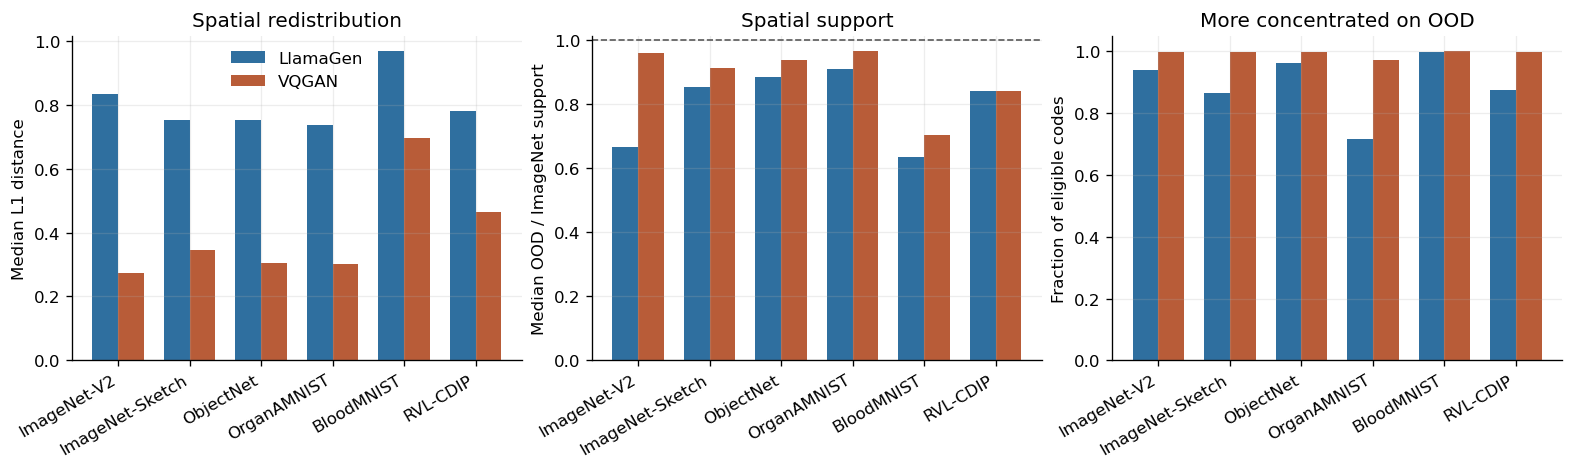

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), constrained_layout=True)
spatial_specs = [
    ("median_l1_distance", "Median L1 distance", "Spatial redistribution"),
    ("median_effective_support_ratio", "Median OOD / ImageNet support", "Spatial support"),
    ("fraction_more_spatially_concentrated", "Fraction of eligible codes", "More concentrated on OOD"),
]
for ax, (metric, ylabel, title) in zip(axes, spatial_specs):
    for offset, model in [(-width / 2, "LlamaGen"), (width / 2, "VQGAN")]:
        values = spatial_summary[spatial_summary["model"] == model].set_index("dataset").loc[ood_datasets, metric]
        ax.bar(x + offset, values, width, color=MODEL_COLORS[model], label=model)
    if metric == "median_effective_support_ratio":
        ax.axhline(1.0, color="0.35", linestyle="--", linewidth=1)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels([DATASET_LABELS[d] for d in ood_datasets], rotation=30, ha="right")
axes[0].legend(frameon=False)
save_figure(fig, "ch08_spatial_shift_summary.png")
plt.show()


### Representative Spatial Shifts

For each model and OOD dataset, three eligible codes are selected from the empirical L1-distance distribution: the 10th percentile (stable), median, and 90th percentile (strong shift). Selection occurs independently within each model. These heatmaps illustrate the aggregate result without treating a few manually chosen codes as evidence.


saved: /exp/notebooks/chapter8_outputs/figures/ch08_representative_spatial_shifts_imagenet_v2.png


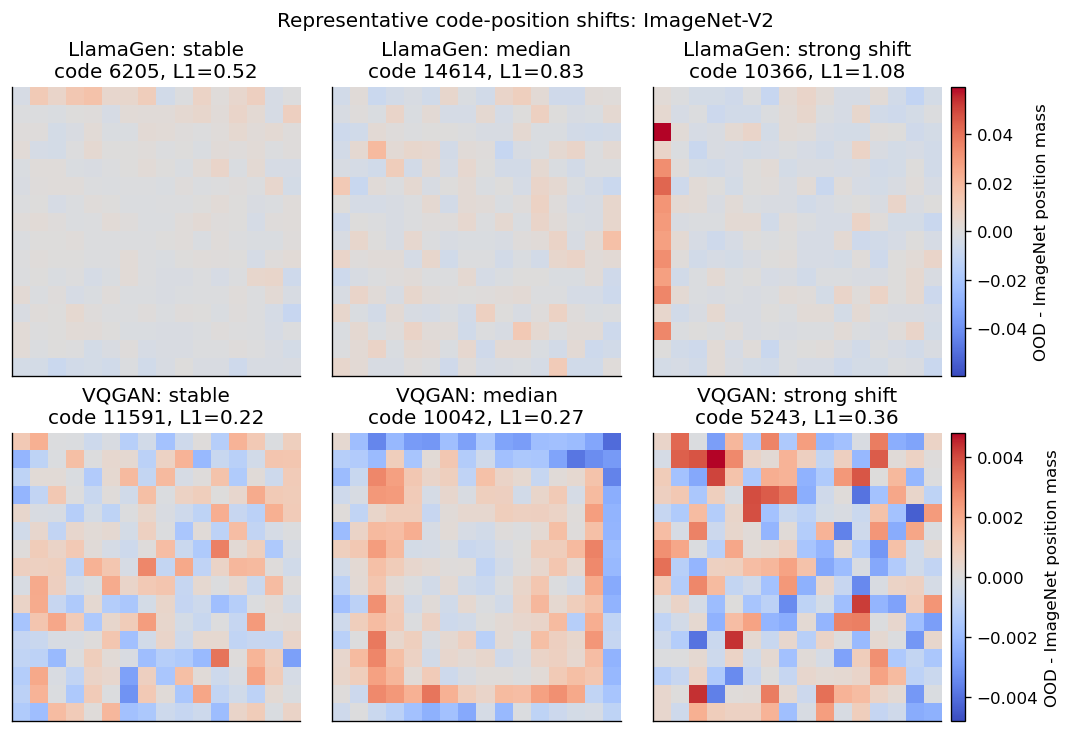

saved: /exp/notebooks/chapter8_outputs/figures/ch08_representative_spatial_shifts_imagenet_sketch.png


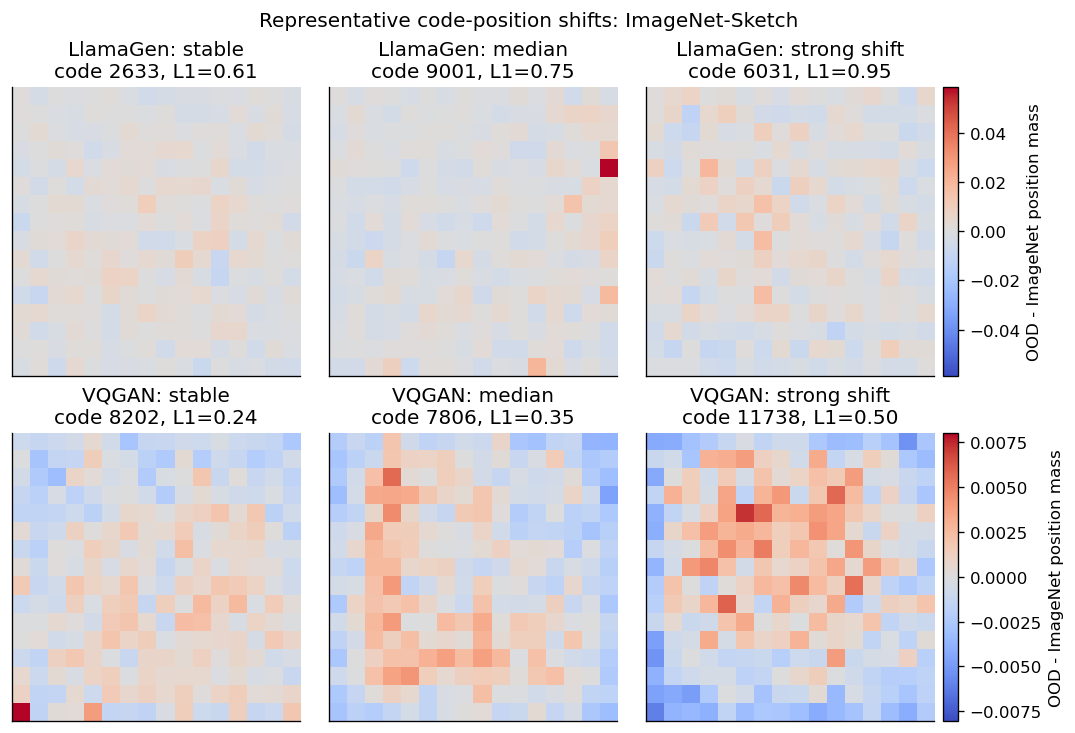

saved: /exp/notebooks/chapter8_outputs/figures/ch08_representative_spatial_shifts_objectnet.png


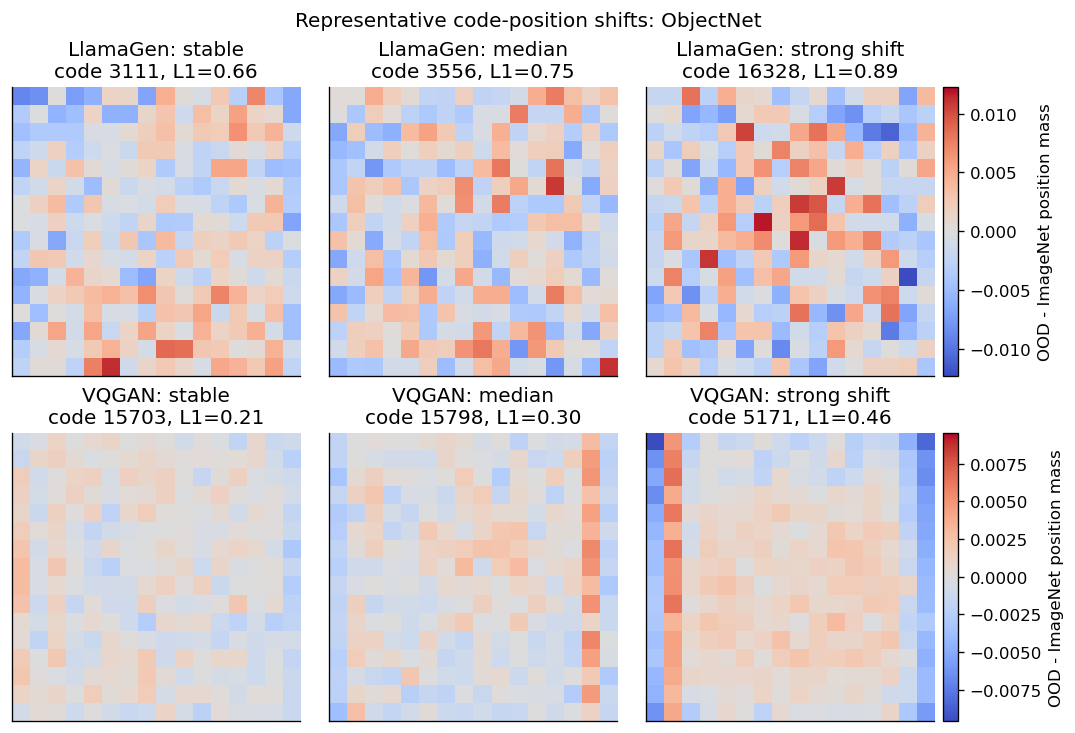

saved: /exp/notebooks/chapter8_outputs/figures/ch08_representative_spatial_shifts_organamnist.png


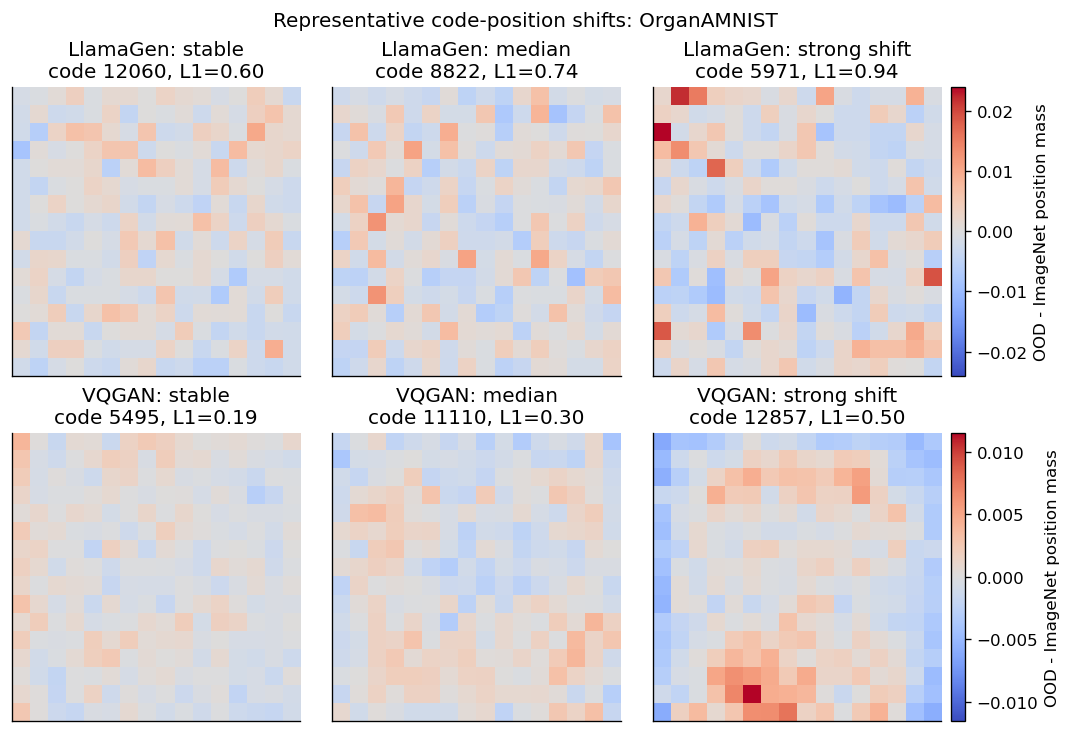

saved: /exp/notebooks/chapter8_outputs/figures/ch08_representative_spatial_shifts_bloodmnist.png


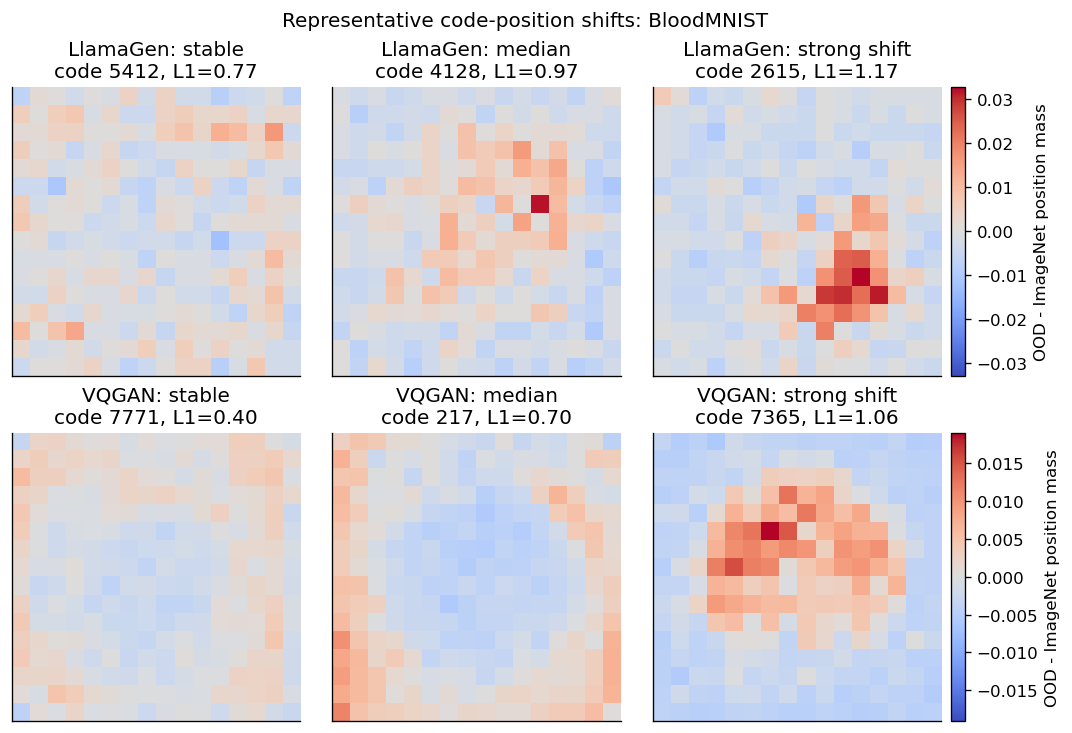

saved: /exp/notebooks/chapter8_outputs/figures/ch08_representative_spatial_shifts_rvlcdip.png


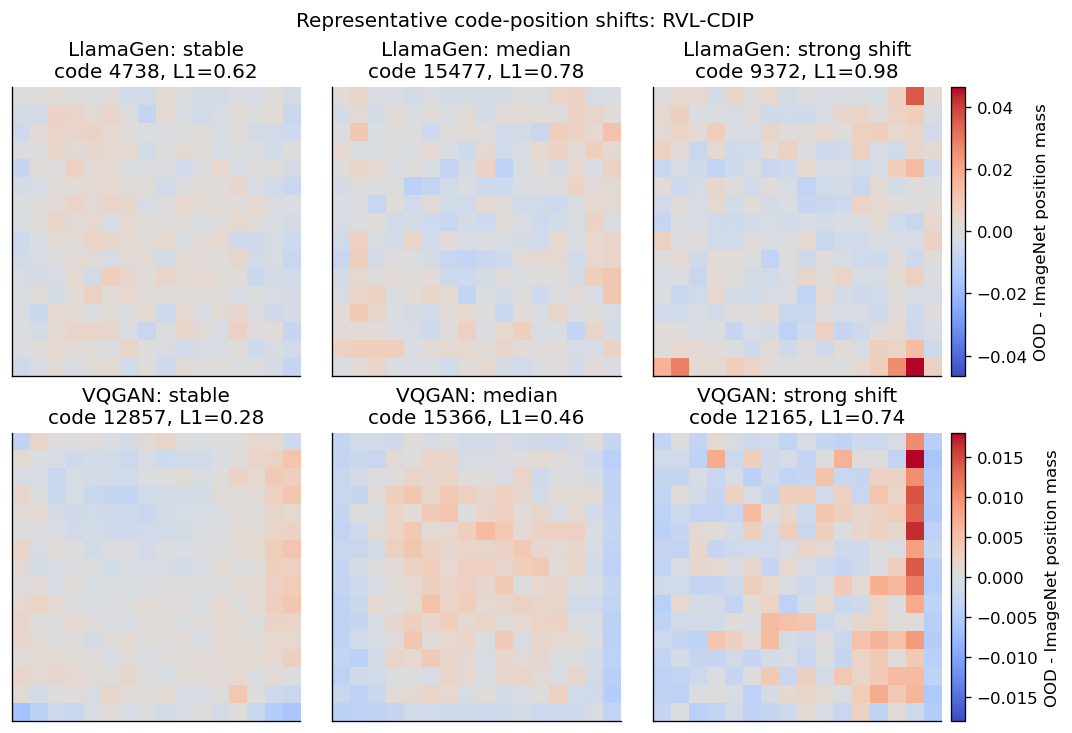

saved: /exp/notebooks/chapter8_outputs/data/ch08_representative_spatial_codes.csv


PosixPath('/exp/notebooks/chapter8_outputs/data/ch08_representative_spatial_codes.csv')

In [13]:
representative_rows = []
quantiles = [(0.10, "stable"), (0.50, "median"), (0.90, "strong shift")]

for dataset in ood_datasets:
    fig, axes = plt.subplots(2, 3, figsize=(9, 6), constrained_layout=True)
    for row, model in enumerate(MODEL_ORDER):
        subset = spatial_code_shift[
            (spatial_code_shift["model"] == model) &
            (spatial_code_shift["dataset"] == dataset)
        ].sort_values("l1_spatial_distance")
        baseline_maps = normalized_position_maps(runs[model][IN_DISTRIBUTION_DATASET]["position_counts"])
        shifted_maps = normalized_position_maps(runs[model][dataset]["position_counts"])

        selected = []
        for quantile, label in quantiles:
            target = subset["l1_spatial_distance"].quantile(quantile)
            index = (subset["l1_spatial_distance"] - target).abs().idxmin()
            selected.append((subset.loc[index], label))

        limit = max(
            np.abs(shifted_maps[int(item.code_id)] - baseline_maps[int(item.code_id)]).max()
            for item, _ in selected
        )
        for col, (item, label) in enumerate(selected):
            code_id = int(item.code_id)
            delta = shifted_maps[code_id] - baseline_maps[code_id]
            image = axes[row, col].imshow(delta, vmin=-limit, vmax=limit, cmap="coolwarm")
            axes[row, col].set_title(f"{model}: {label}\ncode {code_id}, L1={item.l1_spatial_distance:.2f}")
            axes[row, col].set_xticks([])
            axes[row, col].set_yticks([])
            representative_rows.append({
                "model": model,
                "dataset": dataset,
                "selection": label,
                "code_id": code_id,
                "l1_spatial_distance": item.l1_spatial_distance,
            })
        fig.colorbar(image, ax=axes[row, :], fraction=0.018, pad=0.01, label="OOD - ImageNet position mass")
    fig.suptitle(f"Representative code-position shifts: {DATASET_LABELS[dataset]}")
    save_figure(fig, f"ch08_representative_spatial_shifts_{dataset}.png")
    plt.show()

representative_codes = pd.DataFrame(representative_rows)
save_table(representative_codes, "ch08_representative_spatial_codes.csv")


## 10. Joint Chapter Summary


In [14]:
joint_summary = (
    global_summary[global_summary["dataset"] != IN_DISTRIBUTION_DATASET]
    .merge(
        entropy_summary.drop(columns="dataset_label"),
        on=["model", "dataset"],
        how="left",
    )
    .merge(
        spatial_summary.drop(columns="dataset_label"),
        on=["model", "dataset"],
        how="left",
    )
    .merge(
        recon_summary.drop(columns=["dataset", "dataset_label"], errors="ignore"),
        left_on=["model", "dataset"],
        right_on=["model", "dataset_key"],
        how="left",
    )
    .drop(columns="dataset_key")
)

joint_columns = [
    "model", "dataset_label", "n_images",
    "psnr_mean", "ssim_mean", "lpips_mean", "fid",
    "js_divergence_vs_imagenet", "perplexity_ratio_vs_imagenet", "top_100_mass",
    "mean_entropy_delta", "median_l1_distance",
    "median_effective_support_ratio", "fraction_more_spatially_concentrated",
]
joint_summary = joint_summary[joint_columns].sort_values(["dataset_label", "model"])
save_table(joint_summary, "ch08_joint_summary.csv")
display(joint_summary)


saved: /exp/notebooks/chapter8_outputs/data/ch08_joint_summary.csv


,model,dataset_label,n_images,psnr_mean,ssim_mean,lpips_mean,fid,js_divergence_vs_imagenet,perplexity_ratio_vs_imagenet,top_100_mass,mean_entropy_delta,median_l1_distance,median_effective_support_ratio,fraction_more_spatially_concentrated
4,LlamaGen,BloodMNIST,17092,27.101034,0.802003,0.157412,19.601578,0.225963,0.359151,0.129320,-1.551854,0.966906,0.634683,0.996429
10,VQGAN,BloodMNIST,17092,26.379670,0.766061,0.200647,29.015836,0.157481,0.496678,0.449999,-1.003439,0.695663,0.705450,0.998705
1,LlamaGen,ImageNet-Sketch,50889,20.258672,0.752088,0.127749,3.688820,0.153144,0.376723,0.186389,-1.165705,0.753063,0.853392,0.864153
7,VQGAN,ImageNet-Sketch,50889,18.226843,0.695854,0.169755,5.976393,0.127654,0.451836,0.455783,-0.904052,0.346390,0.913515,0.995872
0,LlamaGen,ImageNet-V2,10000,20.953198,0.571562,0.230828,4.340310,0.002027,0.994790,0.012407,-0.682498,0.832181,0.665508,0.937500
6,VQGAN,ImageNet-V2,10000,19.831684,0.501436,0.288779,7.479044,0.000388,1.000681,0.164576,-0.039035,0.274610,0.960137,0.996901
2,LlamaGen,ObjectNet,50273,23.878325,0.683478,0.207518,2.932945,0.020025,0.915833,0.029941,-0.297874,0.751752,0.883725,0.961635
8,VQGAN,ObjectNet,50273,22.792442,0.610994,0.268003,5.796088,0.006820,0.961554,0.197147,-0.130847,0.304871,0.939769,0.996904
3,LlamaGen,OrganAMNIST,57187,26.791059,0.805230,0.182356,57.158006,0.103524,0.624209,0.070029,-0.543501,0.738119,0.911643,0.716549
9,VQGAN,OrganAMNIST,57187,26.580238,0.732107,0.239020,76.118254,0.042356,0.816045,0.269001,-0.248847,0.300525,0.965075,0.972136


## 11. Interpretation Boundaries

- Active-code counts are sample-size dependent. They are retained as descriptive inventory values, not the main distribution-shift result.
- Positional entropy is also sample-size dependent because each position receives one observation per image. The current entropy deltas are not corrected by equal-size resampling.
- LlamaGen frequently saturates its nominal codebook and VQGAN frequently saturates its much smaller empirical active vocabulary. Probability-based concentration and divergence are therefore more informative than strict activity alone.
- Ranked curves compare distribution shapes; a rank does not preserve code identity across datasets.
- Numeric code IDs preserve identity across datasets only within one model. They do not align LlamaGen and VQGAN semantics.
- The spatial analysis is aggregate and descriptive. The 256-count eligibility threshold is low relative to a 256-cell grid, particularly for LlamaGen, and the available artifacts do not support image-level confidence intervals or an equal-size sampling-noise baseline.
- FID is interpreted within each dataset. Large cross-domain FID differences can reflect reference-domain geometry as well as reconstruction degradation.


## 12. Chapter Notes


In [15]:
def fmt(value: float, digits: int = 3) -> str:
    return f"{value:.{digits}f}"


notes = [
    "# Chapter 8 generated notes",
    "",
    f"The analysis includes {len(datasets)} datasets and {len(MODEL_ORDER)} tokenizer models.",
    "ImageNet is the fixed in-distribution reference for every comparison.",
    "",
]
for dataset in ood_datasets:
    notes.append(f"## {DATASET_LABELS[dataset]}")
    for model in MODEL_ORDER:
        global_row = global_summary[(global_summary.model == model) & (global_summary.dataset == dataset)].iloc[0]
        spatial_row = spatial_summary[(spatial_summary.model == model) & (spatial_summary.dataset == dataset)].iloc[0]
        notes.append(
            f"- {model}: JSD={fmt(global_row.js_divergence_vs_imagenet)}, "
            f"perplexity ratio={fmt(global_row.perplexity_ratio_vs_imagenet)}, "
            f"median spatial L1={fmt(spatial_row.median_l1_distance)}, "
            f"median spatial-support ratio={fmt(spatial_row.median_effective_support_ratio)}."
        )
    notes.append("")

notes_path = DATA_DIR / "ch08_chapter_notes.md"
notes_path.write_text("\n".join(notes) + "\n")
print(f"saved: {notes_path}")
print("\n".join(notes[:12]))


saved: /exp/notebooks/chapter8_outputs/data/ch08_chapter_notes.md
# Chapter 8 generated notes

The analysis includes 7 datasets and 2 tokenizer models.
ImageNet is the fixed in-distribution reference for every comparison.

## ImageNet-V2
- LlamaGen: JSD=0.002, perplexity ratio=0.995, median spatial L1=0.832, median spatial-support ratio=0.666.
- VQGAN: JSD=0.000, perplexity ratio=1.001, median spatial L1=0.275, median spatial-support ratio=0.960.

## ImageNet-Sketch
- LlamaGen: JSD=0.153, perplexity ratio=0.377, median spatial L1=0.753, median spatial-support ratio=0.853.
- VQGAN: JSD=0.128, perplexity ratio=0.452, median spatial L1=0.346, median spatial-support ratio=0.914.
